Folder dataset ditemukan di D:\tugas_SEM6\machine learning i\uas\dataset\sukulen_augmented!

MEMULAI FITNESS APPROXIMATION (UJI KILAT 10 EPOCH)
Found 3100 files belonging to 2 classes.
Using 2480 files for training.
Found 3100 files belonging to 2 classes.
Using 620 files for validation.
Epoch 1/10
78/78 [==============================] - 61s 774ms/step - loss: 3.2259 - accuracy: 0.5379 - val_loss: 4.3051 - val_accuracy: 0.5403
Epoch 2/10
78/78 [==============================] - 58s 741ms/step - loss: 0.6693 - accuracy: 0.5496 - val_loss: 13.6341 - val_accuracy: 0.5113
Epoch 3/10
78/78 [==============================] - 64s 821ms/step - loss: 0.6204 - accuracy: 0.5915 - val_loss: 26.3082 - val_accuracy: 0.5048
Epoch 4/10
78/78 [==============================] - 64s 816ms/step - loss: 0.5620 - accuracy: 0.6556 - val_loss: 12.2218 - val_accuracy: 0.5613
Epoch 5/10
78/78 [==============================] - 64s 815ms/step - loss: 0.5171 - accuracy: 0.6879 - val_loss: 6.9993 - val_accuracy: 

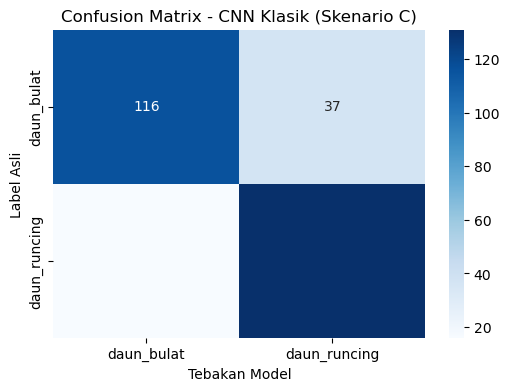


PROSES SELESAI! Model CNN Klasik terbaik telah diamankan di: D:\tugas_SEM6\machine learning i\uas\model_cnn_terbaik.keras


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# =====================================================================
# 1. PENGATURAN PATH LOKAL (WINDOWS)
# =====================================================================
path_dataset = r'D:\tugas_SEM6\machine learning i\uas\dataset\sukulen_augmented'
path_simpan_model = r'D:\tugas_SEM6\machine learning i\uas\model_cnn_terbaik.keras'

if not os.path.exists(path_dataset):
    print(f"PERINGATAN: Folder tidak ditemukan di {path_dataset}!")
    print("Pastikan path sudah benar dan folder tersedia.")
else:
    print(f"Folder dataset ditemukan di {path_dataset}!")

# =====================================================================
# 2. FUNGSI MEMBANGUN MODEL CNN KLASIK
# =====================================================================
def build_model(opt_name, lr, dropout_val):
    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),
        
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_val),
        layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = optimizers.Adam(learning_rate=lr) if opt_name == 'Adam' else optimizers.SGD(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =====================================================================
# 3. FITNESS APPROXIMATION (Uji Kilat 10 Epoch)
# =====================================================================
skenario_list = [
    {"name": "Skenario A", "opt": "Adam", "lr": 0.001, "batch": 32, "drop": 0.2},
    {"name": "Skenario B", "opt": "SGD", "lr": 0.01, "batch": 64, "drop": 0.4},
    {"name": "Skenario C", "opt": "Adam", "lr": 0.0001, "batch": 32, "drop": 0.3}
]

best_score = 0
best_config = None

print("\n" + "="*50)
print("MEMULAI FITNESS APPROXIMATION (UJI KILAT 10 EPOCH)")
print("="*50)

for s in skenario_list:
    train_ds_temp = tf.keras.utils.image_dataset_from_directory(
        path_dataset, validation_split=0.2, subset="training", 
        seed=123, image_size=(224,224), batch_size=s['batch']
    )
    val_ds_temp = tf.keras.utils.image_dataset_from_directory(
        path_dataset, validation_split=0.2, subset="validation", 
        seed=123, image_size=(224,224), batch_size=s['batch']
    )
    
    model_temp = build_model(s['opt'], s['lr'], s['drop'])
    hist = model_temp.fit(train_ds_temp, validation_data=val_ds_temp, epochs=10, verbose=1)
    
    # PERBAIKAN: Mengambil nilai akurasi tertinggi dari keseluruhan 10 epoch
    val_acc = max(hist.history['val_accuracy'])
    print(f"-> {s['name']} selesai | Val Accuracy Terbaik: {val_acc:.4f}")
    
    if val_acc > best_score:
        best_score = val_acc
        best_config = s

print(f"\n>>> KONFIGURASI TERBAIK: {best_config['name']} dengan Akurasi {best_score:.4f} <<<")

# =====================================================================
# 4. FULL TRAINING (Menggunakan Konfigurasi Terbaik)
# =====================================================================
print("\n" + "="*50)
print(f"MEMULAI FULL TRAINING: {best_config['name']}")
print("="*50)

train_ds_final = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="training", 
    seed=123, image_size=(224,224), batch_size=best_config['batch']
)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="validation", 
    seed=123, image_size=(224,224), batch_size=best_config['batch']
)

# PERBAIKAN: Mengacak isi data sebelum dibelah agar kelas tidak terpisah
val_batches = len(val_test_ds)
val_test_ds = val_test_ds.unbatch().shuffle(1000, seed=123).batch(best_config['batch'])

val_ds_final = val_test_ds.take(val_batches // 2)
test_ds_final = val_test_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_final = train_ds_final.prefetch(buffer_size=AUTOTUNE)
val_ds_final = val_ds_final.prefetch(buffer_size=AUTOTUNE)
test_ds_final = test_ds_final.prefetch(buffer_size=AUTOTUNE)

model_final = build_model(best_config['opt'], best_config['lr'], best_config['drop'])

hentikan_awal = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
simpan_terbaik = callbacks.ModelCheckpoint(path_simpan_model, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

history_final = model_final.fit(
    train_ds_final, 
    validation_data=val_ds_final, 
    epochs=100, 
    callbacks=[hentikan_awal, simpan_terbaik]
)


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  daun_bulat       0.88      0.76      0.81       153
daun_runcing       0.78      0.89      0.83       147

    accuracy                           0.82       300
   macro avg       0.83      0.82      0.82       300
weighted avg       0.83      0.82      0.82       300



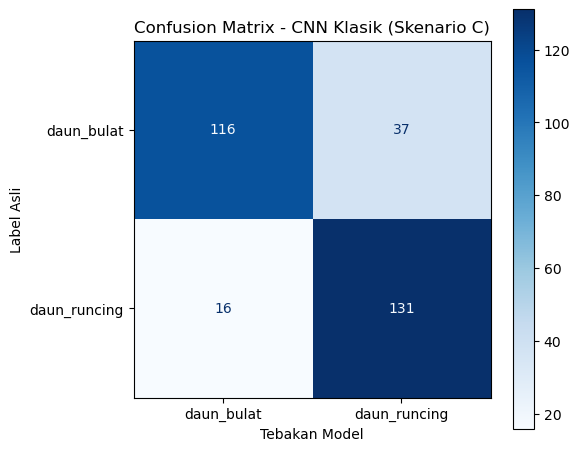


PROSES SELESAI! Model CNN Klasik terbaik telah diamankan di: D:\tugas_SEM6\machine learning i\uas\model_cnn_terbaik.keras

PROSES SELESAI! Model CNN Klasik terbaik telah diamankan di: D:\tugas_SEM6\machine learning i\uas\model_cnn_terbaik.keras


In [ ]:
# =====================================================================
# 5. EVALUASI FINAL 
# =====================================================================
from sklearn.metrics import ConfusionMatrixDisplay

# ... (Pastikan y_true dan y_pred sudah ada dari proses run sebelumnya) ...
# Jika kamu belum me-restart jupyter, variabel y_true dan y_pred masih tersimpan di memori.

# 1. Classification Report
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=['daun_bulat', 'daun_runcing']))

# 2. Confusion Matrix Menggunakan Scikit-Learn Display
cm = confusion_matrix(y_true, y_pred)

# Inisialisasi visualisasi (Bebas dari bug Seaborn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['daun_bulat', 'daun_runcing'])

# Menggambar plot
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix - CNN Klasik (Skenario C)')
plt.ylabel('Label Asli')
plt.xlabel('Tebakan Model')
plt.tight_layout() # Mencegah teks pinggiran terpotong
plt.show()

print(f"\nPROSES SELESAI! Model CNN Klasik terbaik telah diamankan di: {path_simpan_model}")

print(f"\nPROSES SELESAI! Model CNN Klasik terbaik telah diamankan di: {path_simpan_model}")

CNN + SVM

SVM & HOG

In [20]:
# HOG
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split

# =====================================================================
# PATH LOKAL (WINDOWS)
# =====================================================================
path_runcing = r'D:\tugas_SEM6\machine learning i\uas\dataset\sukulen_augmented\daun_runcing'
path_bulat = r'D:\tugas_SEM6\machine learning i\uas\dataset\sukulen_augmented\daun_bulat'

data_features = []
labels = []

def extract_hog_features(folder_path, label):
    for filename in os.listdir(folder_path):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)

            if img is not None:
                # Standarisasi ukuran dan konversi ke grayscale
                img_resized = cv2.resize(img, (224, 224))
                img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

                # Ekstraksi fitur HOG
                features = hog(img_gray, orientations=9, pixels_per_cell=(32, 32),
                            cells_per_block=(2, 2), block_norm='L2-Hys', transform_sqrt=True)

                data_features.append(features)
                labels.append(label)

print("Sedang mengekstrak fitur HOG (Proses ini mungkin memakan waktu beberapa menit di CPU)....")
extract_hog_features(path_runcing, 0)
extract_hog_features(path_bulat, 1)

X = np.array(data_features)
y = np.array(labels)

# Pembagian 80:20 (stratify=y memastikan data dikocok dan terbagi rata, aman dari error sebelumnya!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Total data latih: {X_train.shape[0]}, Total data uji: {X_test.shape[0]}")

Sedang mengekstrak fitur HOG (Proses ini mungkin memakan waktu beberapa menit di CPU)....
Total data latih: 2480, Total data uji: 620


In [21]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd
import time
import joblib

hasil_percobaan = []
skenario = [
    # --- KERNEL LINEAR ---
    {"percobaan": 1, "kernel": 'linear', "C": 0.01, "gamma": 'scale'}, 
    {"percobaan": 2, "kernel": 'linear', "C": 0.1, "gamma": 'scale'},  
    {"percobaan": 3, "kernel": 'linear', "C": 1.0, "gamma": 'scale'},  
    {"percobaan": 4, "kernel": 'linear', "C": 10.0, "gamma": 'scale'}, 

    # --- KERNEL RBF ---
    {"percobaan": 5, "kernel": 'rbf', "C": 0.1, "gamma": 'scale'},     
    {"percobaan": 6, "kernel": 'rbf', "C": 1.0, "gamma": 'scale'},     
    {"percobaan": 7, "kernel": 'rbf', "C": 1.0, "gamma": 'auto'},      
    {"percobaan": 8, "kernel": 'rbf', "C": 10.0, "gamma": 0.001},    
    {"percobaan": 9, "kernel": 'rbf', "C": 50.0, "gamma": 0.0001},   

    # --- KERNEL POLYNOMIAL ---
    {"percobaan": 10, "kernel": 'poly', "C": 1.0, "gamma": 'scale'}    
]

model_terbaik = None
akurasi_test_terbaik = 0
path_simpan_svm_hog = r'D:\tugas_SEM6\machine learning i\uas\model_svm_hog_terbaik.pkl'

print("Mulai proses training eksperimen model...\n")

for s in skenario:
    start_time = time.time()
    svm_model = SVC(kernel=s['kernel'], C=s['C'], gamma=s['gamma'], random_state=42)
    svm_model.fit(X_train, y_train)

    y_pred_train = svm_model.predict(X_train)
    akurasi_train = accuracy_score(y_train, y_pred_train)

    y_pred_test = svm_model.predict(X_test)
    akurasi_test = accuracy_score(y_test, y_pred_test)
    error_rate_test = 1.0 - akurasi_test
    waktu = time.time() - start_time

    hasil_percobaan.append([
        s['percobaan'], s['kernel'], s['C'], s['gamma'],
        f"{akurasi_train*100:.2f}%", f"{akurasi_test*100:.2f}%", f"{error_rate_test:.4f}"
    ])

    if akurasi_test > akurasi_test_terbaik:
        akurasi_test_terbaik = akurasi_test
        model_terbaik = svm_model

# MENYIMPAN MODEL TERBAIK
joblib.dump(model_terbaik, path_simpan_svm_hog)
print(f"Model SVM+HOG terbaik berhasil diamankan di: {path_simpan_svm_hog}")

df_hasil = pd.DataFrame(hasil_percobaan, columns=[
    'Percobaan', 'Kernel', 'Parameter C', 'Gamma',
    'Akurasi Training', 'Akurasi Testing', 'Error Rate (Testing)'
])

print(df_hasil.to_string(index=False))
print(f"\nModel terbaik ditemukan pada percobaan dengan akurasi testing: {akurasi_test_terbaik*100:.2f}%")

Mulai proses training eksperimen model...

Model SVM+HOG terbaik berhasil diamankan di: D:\tugas_SEM6\machine learning i\uas\model_svm_hog_terbaik.pkl
 Percobaan Kernel  Parameter C   Gamma Akurasi Training Akurasi Testing Error Rate (Testing)
         1 linear         0.01   scale           65.60%          66.61%               0.3339
         2 linear         0.10   scale           73.59%          70.32%               0.2968
         3 linear         1.00   scale           82.70%          70.81%               0.2919
         4 linear        10.00   scale           92.06%          71.94%               0.2806
         5    rbf         0.10   scale           70.93%          69.03%               0.3097
         6    rbf         1.00   scale           94.60%          81.77%               0.1823
         7    rbf         1.00    auto           65.16%          65.16%               0.3484
         8    rbf        10.00   0.001           67.30%          67.42%               0.3258
         9  

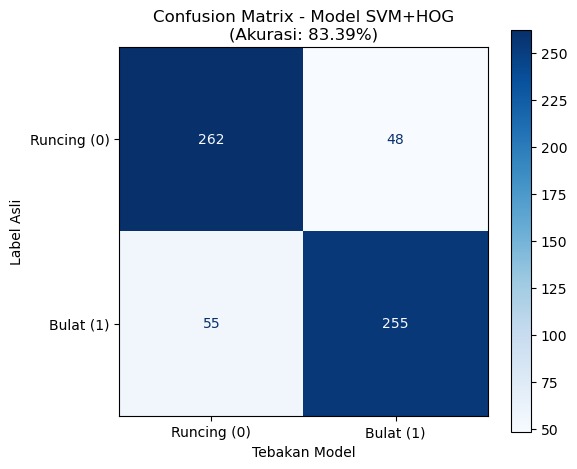


--- Metrik Evaluasi Model Terbaik ---
                  precision    recall  f1-score   support

Daun Runcing (0)       0.83      0.85      0.84       310
  Daun Bulat (1)       0.84      0.82      0.83       310

        accuracy                           0.83       620
       macro avg       0.83      0.83      0.83       620
    weighted avg       0.83      0.83      0.83       620



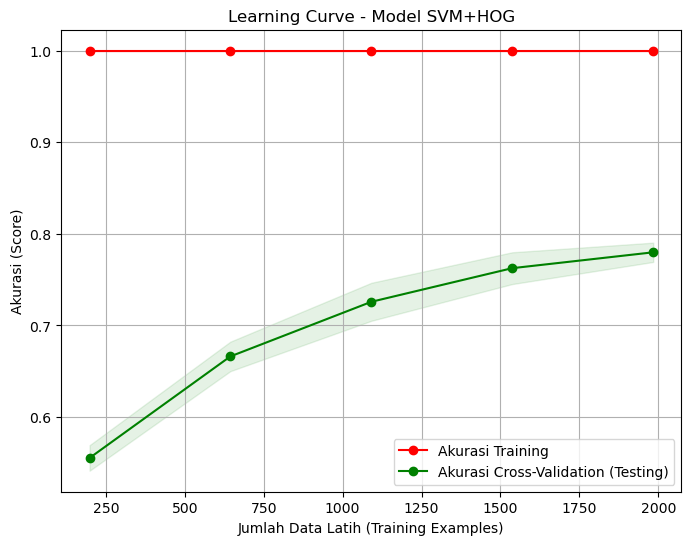

In [24]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import learning_curve

# =====================================================================
# 1. EVALUASI (Dengan Perbaikan Visual Confusion Matrix)
# =====================================================================
# Prediksi
y_pred_best = model_terbaik.predict(X_test)

# Hitung ulang akurasi secara langsung agar tidak error
akurasi_hitung_ulang = accuracy_score(y_test, y_pred_best)

cm = confusion_matrix(y_test, y_pred_best)

# Inisialisasi visualisasi dari Scikit-Learn (Anti-Bug)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Runcing (0)', 'Bulat (1)'])

# Menggambar plot
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')

# Memanggil variabel akurasi yang baru dihitung
plt.title(f'Confusion Matrix - Model SVM+HOG\n(Akurasi: {akurasi_hitung_ulang*100:.2f}%)')
plt.ylabel('Label Asli')
plt.xlabel('Tebakan Model')
plt.tight_layout()
plt.show()

print("\n--- Metrik Evaluasi Model Terbaik ---")
print(classification_report(y_test, y_pred_best, target_names=['Daun Runcing (0)', 'Daun Bulat (1)']))


# =====================================================================
# 2. LEARNING CURVE
# =====================================================================
def plot_learning_curve(estimator, title, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.xlabel("Jumlah Data Latih (Training Examples)")
    plt.ylabel("Akurasi (Score)")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.1, color="g")

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Akurasi Training")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Akurasi Cross-Validation (Testing)")
    plt.legend(loc="best")
    return plt

g = plot_learning_curve(model_terbaik, "Learning Curve - Model SVM+HOG", X_train, y_train, cv=5)
plt.show()

In [25]:
# PERBANDINGAN SVM DAN SVM + HOG
raw_features = []
labels_raw = []

def extract_raw_pixels(folder_path, label):
    for filename in os.listdir(folder_path):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)

            if img is not None:
                img_resized = cv2.resize(img, (64, 64))
                raw_features.append(img_resized.flatten() / 255.0)
                labels_raw.append(label)

print("Sedang mengekstrak raw pixels....")
extract_raw_pixels(path_runcing, 0)
extract_raw_pixels(path_bulat, 1)

X_raw = np.array(raw_features)
y_raw = np.array(labels_raw)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

print("\nMulai training SVM Tanpa HOG (Raw Pixels)...")
svm_raw = SVC(kernel='linear', C=0.1, random_state=42)
svm_raw.fit(X_train_raw, y_train_raw)

y_pred_train_raw = svm_raw.predict(X_train_raw)
y_pred_test_raw = svm_raw.predict(X_test_raw)

print(f"--- Akurasi Training (Raw Pixels): {accuracy_score(y_train_raw, y_pred_train_raw)*100:.2f}% ---")
print(f"--- Akurasi Testing (Raw Pixels) : {accuracy_score(y_test_raw, y_pred_test_raw)*100:.2f}% ---\n")

# TABEL PERBANDINGAN FINAL
from sklearn.metrics import precision_score, recall_score, f1_score

data_hasil = [
    {
        "Model": "SVM (Raw Pixels)", "Jenis Data": "Training (Latih)",
        "Akurasi": f"{accuracy_score(y_train_raw, y_pred_train_raw)*100:.2f}%",
        "Precision": f"{precision_score(y_train_raw, y_pred_train_raw, average='macro')*100:.2f}%",
        "Recall": f"{recall_score(y_train_raw, y_pred_train_raw, average='macro')*100:.2f}%",
        "F1-Score": f"{f1_score(y_train_raw, y_pred_train_raw, average='macro')*100:.2f}%"
    },
    {
        "Model": "SVM (Raw Pixels)", "Jenis Data": "Testing (Uji)",
        "Akurasi": f"{accuracy_score(y_test_raw, y_pred_test_raw)*100:.2f}%",
        "Precision": f"{precision_score(y_test_raw, y_pred_test_raw, average='macro')*100:.2f}%",
        "Recall": f"{recall_score(y_test_raw, y_pred_test_raw, average='macro')*100:.2f}%",
        "F1-Score": f"{f1_score(y_test_raw, y_pred_test_raw, average='macro')*100:.2f}%"
    },
    {
        "Model": "SVM + HOG", "Jenis Data": "Training (Latih)",
        "Akurasi": f"{accuracy_score(y_train, y_pred_train)*100:.2f}%",
        "Precision": f"{precision_score(y_train, y_pred_train, average='macro')*100:.2f}%",
        "Recall": f"{recall_score(y_train, y_pred_train, average='macro')*100:.2f}%",
        "F1-Score": f"{f1_score(y_train, y_pred_train, average='macro')*100:.2f}%"
    },
    {
        "Model": "SVM + HOG", "Jenis Data": "Testing (Uji)",
        "Akurasi": f"{accuracy_score(y_test, y_pred_best)*100:.2f}%",
        "Precision": f"{precision_score(y_test, y_pred_best, average='macro')*100:.2f}%",
        "Recall": f"{recall_score(y_test, y_pred_best, average='macro')*100:.2f}%",
        "F1-Score": f"{f1_score(y_test, y_pred_best, average='macro')*100:.2f}%"
    }
]

df_evaluasi_total = pd.DataFrame(data_hasil)
print("=================== TABEL EVALUASI DAN PERBANDINGAN MODEL UTS vs BASELINE ===================\n")
display(df_evaluasi_total)

Sedang mengekstrak raw pixels....

Mulai training SVM Tanpa HOG (Raw Pixels)...
--- Akurasi Training (Raw Pixels): 100.00% ---
--- Akurasi Testing (Raw Pixels) : 74.52% ---

=================== TABEL EVALUASI DAN PERBANDINGAN MODEL UTS vs BASELINE ===================

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "d:\anaconda3\envs\myenv\lib\site-packages\IPython\core\formatters.py", line 223, in catch_format_error
    r = method(self, *args, **kwargs)
  File "d:\anaconda3\envs\myenv\lib\site-packages\IPython\core\formatters.py", line 344, in __call__
    return method()
  File "d:\anaconda3\envs\myenv\lib\site-packages\pandas\core\frame.py", line 1175, in _repr_html_
    else:
  File "d:\anaconda3\envs\myenv\lib\site-packages\pandas\io\formats\format.py", line 1074, in to_html
  File "d:\anaconda3\envs\myenv\lib\site-packages\pandas\io\formats\html.py", line 88, in to_string
    lines = self.render()
  File "d:\anaconda3\envs\myenv\lib\site-packages\pandas\io\formats\html.py", line 644, in render
    super().render()
  File "d:\anaconda3\envs\myenv\lib\site-packages\pandas\io\formats\html.py", line 94, in render
    self._write_table()
  File "d:\anaconda3\envs\myenv\lib\site-packages\pandas\io\formats\html.py", line 267, in _write_table
    self._writ

              Model        Jenis Data  Akurasi Precision   Recall F1-Score
0  SVM (Raw Pixels)  Training (Latih)  100.00%   100.00%  100.00%  100.00%
1  SVM (Raw Pixels)     Testing (Uji)   74.52%    74.57%   74.52%   74.50%
2         SVM + HOG  Training (Latih)  100.00%   100.00%  100.00%  100.00%
3         SVM + HOG     Testing (Uji)   83.39%    83.40%   83.39%   83.38%

CNN SVM

Memuat dataset untuk ekstraksi fitur...
Found 3100 files belonging to 2 classes.
Using 2480 files for training.
Found 3100 files belonging to 2 classes.
Using 620 files for validation.

Memuat Model CNN...
Model siap! Mengekstrak fitur numerik dari layer: dropout_16
Mengekstrak fitur Data Training (Tunggu sebentar, CPU sedang bekerja keras)...
Mengekstrak fitur Data Testing...
Bentuk Array Fitur Training: (2480, 64) | Bentuk Label: (2480,)

MELATIH & EVALUASI: Skenario 1 (RBF, C=1.0)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  daun_bulat       0.84      0.90      0.87       148
daun_runcing       0.89      0.83      0.86       152

    accuracy                           0.86       300
   macro avg       0.87      0.86      0.86       300
weighted avg       0.87      0.86      0.86       300



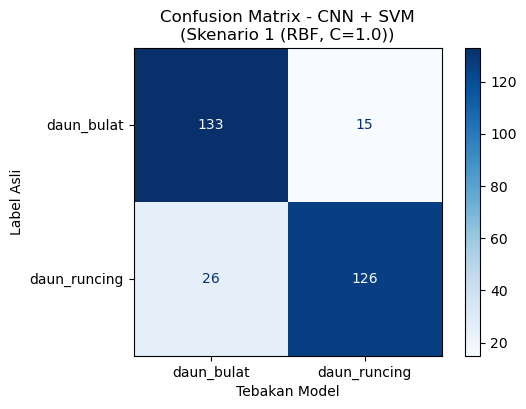


MELATIH & EVALUASI: Skenario 2 (Linear, C=1.0)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  daun_bulat       0.87      0.87      0.87       148
daun_runcing       0.87      0.87      0.87       152

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300



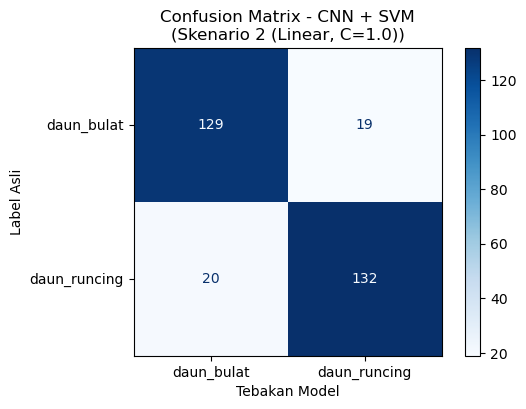


MELATIH & EVALUASI: Skenario 3 (RBF, C=10.0)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  daun_bulat       0.86      0.88      0.87       148
daun_runcing       0.88      0.86      0.87       152

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300



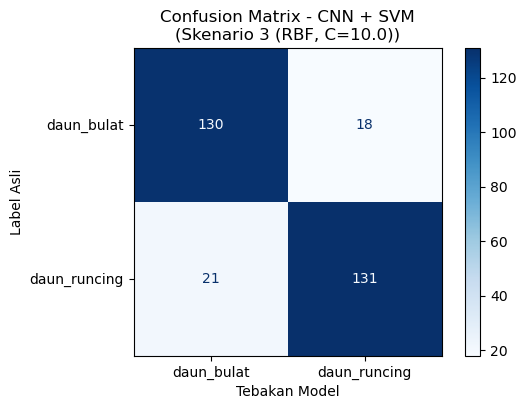


PROSES SELESAI! Model terbaik adalah: Skenario 2 (Linear, C=1.0)
Akurasi Terbaik: 87.00%
Model berhasil diamankan di: D:\tugas_SEM6\machine learning i\uas\model_svm_terbaik.pkl


In [27]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # Pustaka wajib untuk menyimpan model ML Tradisional

# =====================================================================
# 1. PENGATURAN PATH
# =====================================================================
path_dataset = r'D:\tugas_SEM6\machine learning i\uas\dataset\sukulen_augmented'
path_model_cnn = r'D:\tugas_SEM6\machine learning i\uas\model_cnn_terbaik.keras' 
path_simpan_svm = r'D:\tugas_SEM6\machine learning i\uas\model_svm_terbaik.pkl' # Tempat simpan SVM

# Memuat Dataset
print("Memuat dataset untuk ekstraksi fitur...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="training", 
    seed=123, image_size=(224,224), batch_size=32
)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="validation", 
    seed=123, image_size=(224,224), batch_size=32
)

val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.skip(val_batches // 2)

# =====================================================================
# 2. MENGUBAH CNN MENJADI EKSTRAKTOR FITUR
# =====================================================================
print("\nMemuat Model CNN...")
cnn_model = load_model(path_model_cnn)

# Memotong layer klasifikasi terakhir. 
# Mengambil output dari layer sebelum Dense terakhir (contoh: Flatten/Dropout)
layer_nama = cnn_model.layers[-2].name 
feature_extractor = Model(inputs=cnn_model.inputs, outputs=cnn_model.get_layer(layer_nama).output)

print(f"Model siap! Mengekstrak fitur numerik dari layer: {layer_nama}")

def extract_features(dataset, extractor):
    features = []
    labels = []
    for images, lbls in dataset:
        preds = extractor.predict(images, verbose=0)
        features.append(preds)
        labels.append(lbls.numpy())
    return np.vstack(features), np.concatenate(labels)

print("Mengekstrak fitur Data Training (Tunggu sebentar, CPU sedang bekerja keras)...")
X_train, y_train = extract_features(train_ds, feature_extractor)

print("Mengekstrak fitur Data Testing...")
X_test, y_test = extract_features(test_ds, feature_extractor)

print(f"Bentuk Array Fitur Training: {X_train.shape} | Bentuk Label: {y_train.shape}")

# =====================================================================
# 3. TRAINING, EVALUASI & PENYIMPANAN SKENARIO SVM
# =====================================================================
skenario_svm = [
    {"nama": "Skenario 1 (RBF, C=1.0)", "kernel": 'rbf', "C": 1.0, "gamma": 'scale'},
    {"nama": "Skenario 2 (Linear, C=1.0)", "kernel": 'linear', "C": 1.0, "gamma": 'scale'},
    {"nama": "Skenario 3 (RBF, C=10.0)", "kernel": 'rbf', "C": 10.0, "gamma": 'scale'}
]

best_svm_acc = 0
best_svm_model = None
nama_svm_terbaik = ""

for s in skenario_svm:
    print(f"\n{'='*50}")
    print(f"MELATIH & EVALUASI: {s['nama']}")
    print(f"{'='*50}")
    
    # Inisialisasi dan Training SVM
    svm_clf = SVC(kernel=s['kernel'], C=s['C'], gamma=s['gamma'], random_state=123)
    svm_clf.fit(X_train, y_train)
    
    # Prediksi Data Testing
    y_pred = svm_clf.predict(X_test)
    
    # Hitung Akurasi untuk menentukan model terbaik
    acc = accuracy_score(y_test, y_pred)
    if acc > best_svm_acc:
        best_svm_acc = acc
        best_svm_model = svm_clf
        nama_svm_terbaik = s['nama']
    
    # Classification Report
    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(y_test, y_pred, target_names=['daun_bulat', 'daun_runcing']))
    
    # Confusion Matrix
# Ganti blok Confusion Matrix yang lama dengan ini:
    from sklearn.metrics import ConfusionMatrixDisplay
    cm = confusion_matrix(y_test, y_pred)
    
    # Menggunakan ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['daun_bulat', 'daun_runcing'])
    
    fig, ax = plt.subplots(figsize=(6, 4))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    
    plt.title(f'Confusion Matrix - CNN + SVM\n({s["nama"]})')
    plt.ylabel('Label Asli')
    plt.xlabel('Tebakan Model')
    plt.show()

# MENYIMPAN MODEL TERBAIK KE LOKAL
joblib.dump(best_svm_model, path_simpan_svm)
print("\n" + "="*50)
print(f"PROSES SELESAI! Model terbaik adalah: {nama_svm_terbaik}")
print(f"Akurasi Terbaik: {best_svm_acc*100:.2f}%")
print(f"Model berhasil diamankan di: {path_simpan_svm}")
print("="*50)

In [ ]:
VGG

In [2]:
# =====================================================================
# VGG16 - MULTI SCENARIO (MANDIRI & BEBAS ERROR)
# =====================================================================

import os
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# 1. PENGATURAN PATH LOKAL & LOAD DATASET
path_dataset = r'D:\tugas_SEM6\machine learning i\uas\dataset\sukulen_augmented'
PATH_MODEL_VGG = r"D:\tugas_SEM6\machine learning i\uas\model_vgg16_terbaik.keras"

print("Memuat dataset ke dalam memori...")
batch_size = 32
train_ds_final = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="training", 
    seed=123, image_size=(224,224), batch_size=batch_size
)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="validation", 
    seed=123, image_size=(224,224), batch_size=batch_size
)

# Memecah sisa data menjadi Validation dan Testing
val_batches = len(val_test_ds)
val_test_ds = val_test_ds.unbatch().shuffle(1000, seed=123).batch(batch_size)
val_ds_final = val_test_ds.take(val_batches // 2)
test_ds_final = val_test_ds.skip(val_batches // 2)

# Optimasi prefetch agar komputasi tidak lag
AUTOTUNE = tf.data.AUTOTUNE
train_ds_final = train_ds_final.prefetch(buffer_size=AUTOTUNE)
val_ds_final = val_ds_final.prefetch(buffer_size=AUTOTUNE)
test_ds_final = test_ds_final.prefetch(buffer_size=AUTOTUNE)

# 2. KONFIGURASI SKENARIO HYPERPARAMETER
vgg_skenario = [
    {"nama":"VGG-1", "lr":0.0001, "dropout":0.5, "optimizer":"adam"},
    {"nama":"VGG-2", "lr":0.0001, "dropout":0.3, "optimizer":"adam"},
    {"nama":"VGG-3", "lr":0.00001, "dropout":0.5, "optimizer":"adam"},
    {"nama":"VGG-4", "lr":0.001, "dropout":0.4, "optimizer":"sgd"}
]

best_acc = 0
best_model = None
best_history = None
best_skenario = ""

# 3. PROSES ITERASI PELATIHAN MULTI SCENARIO
for s in vgg_skenario:
    print("\n"+"="*60)
    print("TRAINING", s["nama"])
    print("="*60)

    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    
    base_model.trainable = False

    model = models.Sequential([
        layers.Rescaling(1./255),
        base_model,
        
        # PERBAIKAN KRUSIAL: Gunakan Flatten agar dimensi spasial sudut daun tidak hancur
        layers.Flatten(), 
        
        layers.Dense(128, activation='relu'),
        layers.Dropout(s["dropout"]),
        layers.Dense(1, activation='sigmoid')
    ])

    if s["optimizer"] == "adam":
        opt = optimizers.Adam(learning_rate=s["lr"])
    else:
        opt = optimizers.SGD(learning_rate=s["lr"], momentum=0.9)

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

    early_stop = callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        train_ds_final,
        validation_data=val_ds_final,
        epochs=10,
        callbacks=[early_stop],
        verbose=1
    )

    acc = max(history.history['val_accuracy'])
    print(f"\nBest Validation Accuracy = {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_history = history
        best_skenario = s["nama"]

print("\n")
print("="*60)
print("SKENARIO TERBAIK :", best_skenario)
print("VAL ACC TERBAIK :", best_acc)
print("="*60)

# 4. MENYIMPAN MODEL SEMENTARA
best_model.save(PATH_MODEL_VGG)
print("Model sementara berhasil diamankan di:")
print(PATH_MODEL_VGG)

Memuat dataset ke dalam memori...
Found 3100 files belonging to 2 classes.
Using 2480 files for training.
Found 3100 files belonging to 2 classes.
Using 620 files for validation.

TRAINING VGG-1
Epoch 1/10
78/78 [==============================] - 404s 5s/step - loss: 0.6612 - accuracy: 0.6254 - val_loss: 0.5230 - val_accuracy: 0.7844
Epoch 2/10
78/78 [==============================] - 190s 2s/step - loss: 0.4774 - accuracy: 0.7790 - val_loss: 0.4360 - val_accuracy: 0.8281
Epoch 3/10
78/78 [==============================] - 192s 2s/step - loss: 0.3904 - accuracy: 0.8274 - val_loss: 0.3596 - val_accuracy: 0.8750
Epoch 4/10
78/78 [==============================] - 186s 2s/step - loss: 0.3063 - accuracy: 0.8835 - val_loss: 0.3218 - val_accuracy: 0.8969
Epoch 5/10
78/78 [==============================] - 194s 2s/step - loss: 0.2642 - accuracy: 0.9024 - val_loss: 0.3356 - val_accuracy: 0.8719
Epoch 6/10
78/78 [==============================] - 197s 3s/step - loss: 0.2109 - accuracy: 0.9331 -

In [3]:
# =====================================================================
# FINAL TRAINING VGG16
# =====================================================================

checkpoint_vgg = callbacks.ModelCheckpoint(
    PATH_MODEL_VGG,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_vgg_final = best_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=100,
    callbacks=[
        checkpoint_vgg,
        early_stop
    ]
)

Epoch 1/100
78/78 [==============================] - ETA: 0s - loss: 0.0682 - accuracy: 0.9915
Epoch 1: val_accuracy improved from -inf to 0.90312, saving model to D:\tugas_SEM6\machine learning i\uas\model_vgg16_terbaik.keras
78/78 [==============================] - 559s 7s/step - loss: 0.0682 - accuracy: 0.9915 - val_loss: 0.2353 - val_accuracy: 0.9031
Epoch 2/100
78/78 [==============================] - ETA: 0s - loss: 0.0555 - accuracy: 0.9980
Epoch 2: val_accuracy did not improve from 0.90312
78/78 [==============================] - 553s 7s/step - loss: 0.0555 - accuracy: 0.9980 - val_loss: 0.2311 - val_accuracy: 0.9000
Epoch 3/100
78/78 [==============================] - ETA: 0s - loss: 0.0505 - accuracy: 0.9960
Epoch 3: val_accuracy improved from 0.90312 to 0.93437, saving model to D:\tugas_SEM6\machine learning i\uas\model_vgg16_terbaik.keras
78/78 [==============================] - 561s 7s/step - loss: 0.0505 - accuracy: 0.9960 - val_loss: 0.1668 - val_accuracy: 0.9344
Epoch 4


=== EVALUASI FINAL VGG16 ===

Akurasi Testing : 93.00%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  daun_bulat       0.93      0.91      0.92       140
daun_runcing       0.93      0.94      0.93       160

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



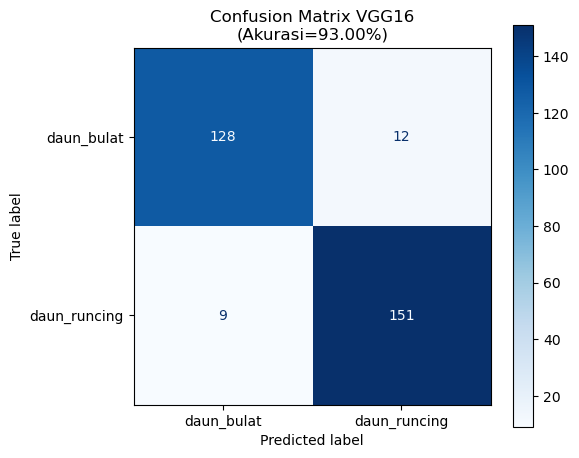

In [4]:
# =====================================================================
# EVALUASI VGG16
# =====================================================================

print("\n=== EVALUASI FINAL VGG16 ===")

y_true = []
y_pred_prob = []

for images, labels in test_ds_final:
    y_true.extend(labels.numpy())
    preds = best_model.predict_on_batch(images)
    y_pred_prob.extend(preds)

y_true = np.array(y_true)
y_pred = (np.array(y_pred_prob) > 0.5).astype("int32")

acc = accuracy_score(y_true, y_pred)
print(f"\nAkurasi Testing : {acc*100:.2f}%")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=['daun_bulat', 'daun_runcing']))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['daun_bulat', 'daun_runcing']
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Confusion Matrix VGG16\n(Akurasi={acc*100:.2f}%)')
plt.tight_layout()
plt.show()

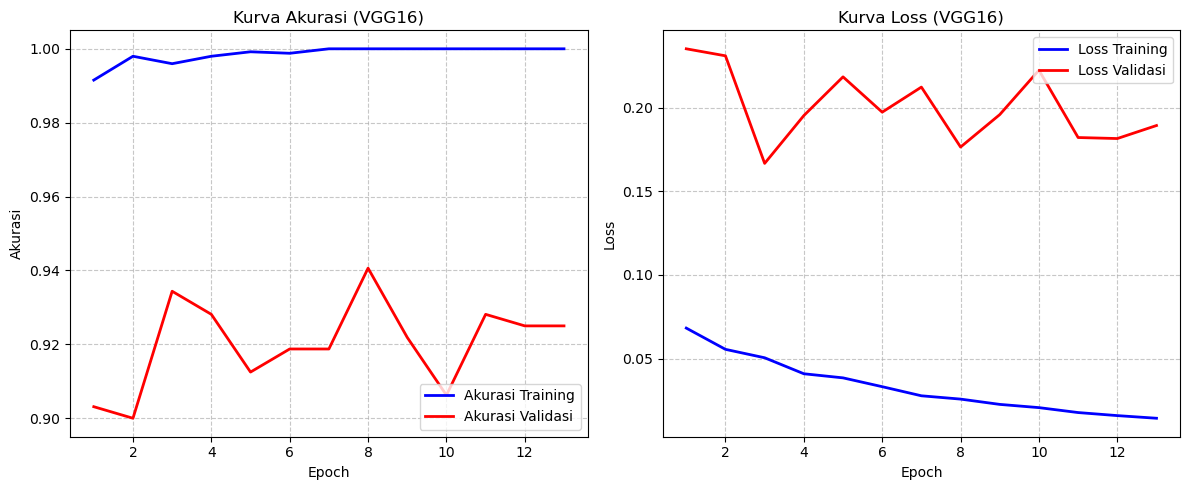

In [5]:
import matplotlib.pyplot as plt

# =====================================================================
# CEK OVERFITTING VGG16 (LEARNING CURVE)
# =====================================================================

# Mengambil data dari variabel history
acc = history_vgg_final.history['accuracy']
val_acc = history_vgg_final.history['val_accuracy']
loss = history_vgg_final.history['loss']
val_loss = history_vgg_final.history['val_loss']

# Menentukan jumlah epoch yang benar-benar berjalan
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# 1. Grafik Akurasi (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-', label='Akurasi Training', linewidth=2)
plt.plot(epochs_range, val_acc, 'r-', label='Akurasi Validasi', linewidth=2)
plt.title('Kurva Akurasi (VGG16)')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Grafik Error (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-', label='Loss Training', linewidth=2)
plt.plot(epochs_range, val_loss, 'r-', label='Loss Validasi', linewidth=2)
plt.title('Kurva Loss (VGG16)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
RESTNET

In [3]:
# =====================================================================
# 1. LOAD DATA & RESNET50 - MULTI SCENARIO (LOKAL)
# =====================================================================

import os
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, callbacks, optimizers
import numpy as np
import matplotlib.pyplot as plt

# PATH LOKAL
path_dataset = r'D:\tugas_SEM6\machine learning i\uas\dataset\sukulen_augmented'
PATH_MODEL_RESNET = r'D:\tugas_SEM6\machine learning i\uas\model_resnet50_terbaik.keras'

# MEMUAT ULANG DATASET (Agar tidak error NameError)
print("Memuat dataset...")
batch_size = 32
train_ds_final = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="training", 
    seed=123, image_size=(224,224), batch_size=batch_size
)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="validation", 
    seed=123, image_size=(224,224), batch_size=batch_size
)

# Memecah data validasi dan testing
val_batches = len(val_test_ds)
val_test_ds = val_test_ds.unbatch().shuffle(1000, seed=123).batch(batch_size)
val_ds_final = val_test_ds.take(val_batches // 2)
test_ds_final = val_test_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_final = train_ds_final.prefetch(buffer_size=AUTOTUNE)
val_ds_final = val_ds_final.prefetch(buffer_size=AUTOTUNE)
test_ds_final = test_ds_final.prefetch(buffer_size=AUTOTUNE)

# SKENARIO HYPERPARAMETER
resnet_skenario = [
    {"nama":"RESNET-1", "lr":0.0001, "dropout":0.5, "optimizer":"adam"},
    {"nama":"RESNET-2", "lr":0.0002, "dropout":0.5, "optimizer":"sgd"},
    {"nama":"RESNET-3", "lr":0.00007, "dropout":0.4, "optimizer":"adam"},
    {"nama":"RESNET-4", "lr":0.0001, "dropout":0.3, "optimizer":"rmsprop"}
]

best_acc = 0
best_model = None
best_history = None
best_skenario = ""

for s in resnet_skenario:
    print("\n"+"="*60)
    print(f"TRAINING {s['nama']}")
    print("="*60)

    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base_model.trainable = False

    model = models.Sequential([
        layers.Rescaling(1./255),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(s["dropout"]),
        layers.Dense(1, activation='sigmoid')
    ])

    # Optimizer
    if s["optimizer"] == "adam":
        opt = optimizers.Adam(learning_rate=s["lr"])
    elif s["optimizer"] == "sgd":
        opt = optimizers.SGD(learning_rate=s["lr"], momentum=0.9)
    else:
        opt = optimizers.RMSprop(learning_rate=s["lr"])

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

    early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)

    history = model.fit(
        train_ds_final, validation_data=val_ds_final,
        epochs=10, callbacks=[early_stop], verbose=1
    )

    acc = max(history.history['val_accuracy'])
    print(f"\nBest Validation Accuracy = {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_history = history
        best_skenario = s["nama"]

print("\n")
print("="*60)
print(f"SKENARIO TERBAIK : {best_skenario}")
print(f"VAL ACC TERBAIK : {best_acc:.4f}")
print("="*60)

# Simpan model sementara
best_model.save(PATH_MODEL_RESNET)
print("\nModel sementara berhasil disimpan di:", PATH_MODEL_RESNET)

Memuat dataset...
Found 3100 files belonging to 2 classes.
Using 2480 files for training.
Found 3100 files belonging to 2 classes.
Using 620 files for validation.

TRAINING RESNET-1
Epoch 1/10
78/78 [==============================] - 160s 2s/step - loss: 0.7861 - accuracy: 0.4976 - val_loss: 0.6905 - val_accuracy: 0.5281
Epoch 2/10
78/78 [==============================] - 175s 2s/step - loss: 0.7233 - accuracy: 0.5101 - val_loss: 0.6959 - val_accuracy: 0.5031
Epoch 3/10
78/78 [==============================] - 175s 2s/step - loss: 0.7101 - accuracy: 0.4964 - val_loss: 0.6839 - val_accuracy: 0.6062
Epoch 4/10
78/78 [==============================] - 158s 2s/step - loss: 0.6983 - accuracy: 0.5214 - val_loss: 0.6941 - val_accuracy: 0.5094
Epoch 5/10
78/78 [==============================] - 181s 2s/step - loss: 0.6917 - accuracy: 0.5218 - val_loss: 0.6858 - val_accuracy: 0.5813
Epoch 6/10
78/78 [==============================] - 182s 2s/step - loss: 0.6852 - accuracy: 0.5532 - val_loss: 0.

In [6]:
# =====================================================================
# 2. FINAL TRAINING & EVALUASI RESNET50
# =====================================================================

print("\n" + "="*60)
print(f"MEMULAI FINAL TRAINING (100 EPOCH) UNTUK: {best_skenario}")
print("="*60)

checkpoint_resnet = callbacks.ModelCheckpoint(
    PATH_MODEL_RESNET,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_final = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,  # bisa 30 atau 10
    restore_best_weights=True,
    verbose=1
)

history_resnet_final = best_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=100,
    callbacks=[checkpoint_resnet, early_stop_final]
)

# EVALUASI FINAL
print("\n=== EVALUASI FINAL RESNET50 ===")
y_true = []
y_pred_prob = []

for images, labels in test_ds_final:
    y_true.extend(labels.numpy())
    preds = best_model.predict_on_batch(images)
    y_pred_prob.extend(preds)

y_true = np.array(y_true)
y_pred = (np.array(y_pred_prob) > 0.5).astype("int32")

akurasi = accuracy_score(y_true, y_pred)
print(f"\nAkurasi Testing ResNet50: {akurasi*100:.2f}%")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=['daun_bulat', 'daun_runcing']))


MEMULAI FINAL TRAINING (100 EPOCH) UNTUK: RESNET-1
Epoch 1/100


78/78 [==============================] - ETA: 0s - loss: 0.6896 - accuracy: 0.5355
Epoch 1: val_accuracy improved from -inf to 0.55937, saving model to D:\tugas_SEM6\machine learning i\uas\model_resnet50_terbaik.keras
78/78 [==============================] - 175s 2s/step - loss: 0.6896 - accuracy: 0.5355 - val_loss: 0.6826 - val_accuracy: 0.5594
Epoch 2/100
78/78 [==============================] - ETA: 0s - loss: 0.6856 - accuracy: 0.5347
Epoch 2: val_accuracy did not improve from 0.55937
78/78 [==============================] - 174s 2s/step - loss: 0.6856 - accuracy: 0.5347 - val_loss: 0.6847 - val_accuracy: 0.5562
Epoch 3/100
78/78 [==============================] - ETA: 0s - loss: 0.6874 - accuracy: 0.5472
Epoch 3: val_accuracy did not improve from 0.55937
78/78 [==============================] - 169s 2s/step - loss: 0.6874 - accuracy: 0.5472 - val_loss: 0.6881 - val_accuracy: 0.5406
Epoch 4/100
78/78 [==============================] - ETA: 0s - loss: 0.6831 - accuracy: 0.5524
Epoch


=== EVALUASI FINAL RESNET50 ===
Akurasi Testing : 53.33%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  daun_bulat       0.51      0.26      0.35       141
daun_runcing       0.54      0.77      0.64       159

    accuracy                           0.53       300
   macro avg       0.52      0.52      0.49       300
weighted avg       0.53      0.53      0.50       300



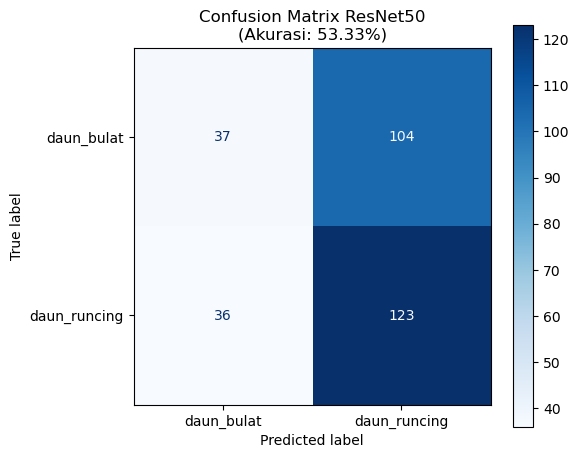

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# =====================================================================
# 1. LOAD MODEL RESNET50 TERLEBIH DAHULU
# =====================================================================
# WAJIB GANTI: Sesuaikan path ini dengan lokasi model ResNet50 Anda yang tersimpan
path_resnet50 = r'D:\tugas_SEM6\machine learning i\uas\model_resnet50_terbaik.keras' 
model_resnet50_terbaik = load_model(path_resnet50)

# =====================================================================
# 2. EVALUASI FINAL RESNET50
# =====================================================================

print("\n=== EVALUASI FINAL RESNET50 ===")

y_true = []
y_pred_prob = []

# Pastikan test_ds_final juga sudah di-load di memori Anda sebelumnya
for images, labels in test_ds_final:
    y_true.extend(labels.numpy())
    preds = model_resnet50_terbaik.predict_on_batch(images)  
    y_pred_prob.extend(preds)

y_true = np.array(y_true)
y_pred = (np.array(y_pred_prob) > 0.5).astype("int32")

# 1. Menghitung Akurasi
akurasi = accuracy_score(y_true, y_pred)
print(f"Akurasi Testing : {akurasi*100:.2f}%\n")

# 2. Menampilkan Precision, Recall, dan F1-Score
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=['daun_bulat', 'daun_runcing']))

# 3. Menampilkan Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['daun_bulat', 'daun_runcing']
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Confusion Matrix ResNet50\n(Akurasi: {akurasi*100:.2f}%)')
plt.tight_layout()
plt.show()

In [ ]:
keseluruhan (manual)

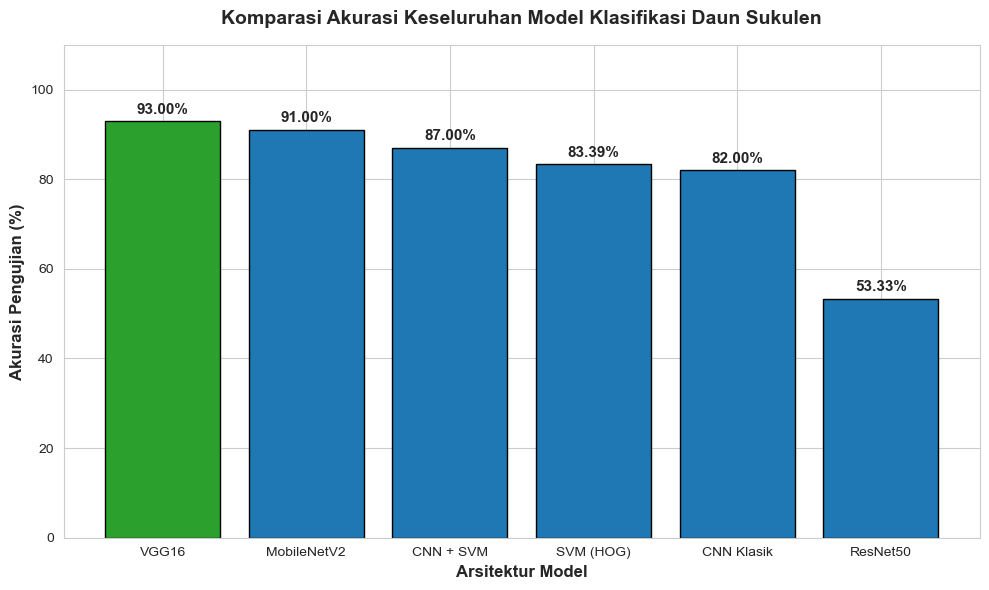

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Akurasi Model
model_names = ['VGG16', 'MobileNetV2', 'CNN + SVM', 'SVM (HOG)', 'CNN Klasik', 'ResNet50']
accuracies = [93.00, 91.00, 87.00, 83.39, 82.00, 53.33]

# 2. Setup Gaya Grafik
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 3. Membuat warna kustom (Warna hijau/biru gelap untuk juara 1, biru terang untuk yang lain)
colors = ['#1f77b4' if acc < 93.00 else '#2ca02c' for acc in accuracies]

# 4. Membuat Bar Chart
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1)

# 5. Menambahkan Teks Nilai (Persentase) di atas setiap batang
for bar in bars:
    yval = bar.get_height()
    # Menambahkan teks tepat di tengah atas bar
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# 6. Menambahkan Label dan Judul
plt.title('Komparasi Akurasi Keseluruhan Model Klasifikasi Daun Sukulen', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Akurasi Pengujian (%)', fontsize=12, fontweight='bold')
plt.xlabel('Arsitektur Model', fontsize=12, fontweight='bold')
plt.ylim(0, 110) # Diberi ruang ekstra di atas agar teks tidak terpotong

# 7. Menampilkan dan Menyimpan Grafik
plt.tight_layout()
# plt.savefig('grafik_komparasi_model.png', dpi=300) # Hilangkan tanda pagar (#) jika ingin otomatis tersimpan jadi file PNG
plt.show()